## Using YiChao's foreground generation code

In [4]:
import numpy as np
import matplotlib.pyplot as plt
print('You will need to download and install the GMS for yourself and add it to your path')
import sys
sys.path.append('/users/mirfan/src/pygdsm/pygdsm/')
#import pygsm
import healpy as hp
from astropy.coordinates import SkyCoord
from astropy import units as u

You will need to download and install the GMS for yourself and add it to your path


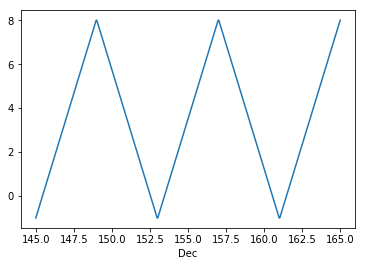

In [2]:
#set up my fake observation which I want to add foregrounds to
ra_list = np.linspace(145, 165, 500)
dec_list = np.hstack((np.linspace(-1, 8, 100), np.linspace(8, -1, 100), np.linspace(-1, 8, 100), \
                         np.linspace(8, -1, 100), np.linspace(-1, 8, 100)))
plt.plot(ra_list, dec_list)
plt.xlabel('R.A')
plt.xlabel('Dec')
plt.show()

num_ch = 100 #how many frequency channels you want 
spac = 0.2 #spacing between your frequency channels in MHz
freq_range = np.linspace(971.2, num_ch*spac+971.2, num_ch) #gives 971.2 to 991.2 MHz 

In [3]:
#get all-sky maps from GSM
GSM = pygsm.GlobalSkyModel(freq_unit='MHz',basemap='haslam') #Haslam means resolution is 56 armcin
fg_model = GSM.generate(freq_range).T
print np.shape(fg_model)

(3145728, 100)


0
20
40
60
80


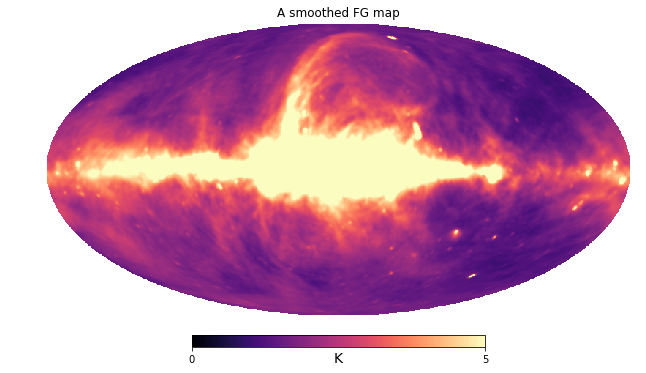

In [4]:
#smooth all sky maps with appropriate Gaussian MK beam (this is the lenghiest part of script)
fwhm1400=0.9
fwhm = 1.2 * fwhm1400 * 1400. / freq_range # in degrees

#downgrading maps to nside 256 as they are uncessarily deailted for our sims 
#and smoothing takes longer for higher nsides
newnside = 256
new_fg_model = np.zeros((12*newnside*newnside, num_ch))
for ff in range(num_ch):
    if ff % 20 == 0:
        print ff
    beam_fwhm = np.sqrt(fwhm[ff]**2 - (56./60.)**2)
    new_map = hp.ud_grade(fg_model[:, ff], nside_out=newnside)
    new_fg_model[:, ff] = hp.smoothing(new_map, fwhm=beam_fwhm * np.pi / 180., verbose=False)
    
hp.mollview(new_fg_model[:,0], cmap='magma', unit='K', title='A smoothed FG map', min=0.0, max=5.0)
plt.show()

In [6]:
#extract the TOD info that we want from the all sky maps
c = SkyCoord(ra=ra_list*u.deg, dec = dec_list*u.deg, frame='icrs')
l = c.galactic.l.radian
b = c.galactic.b.radian
_idx_pix = hp.ang2pix(newnside, np.pi/2.0 - b, l, nest=False)
the_fgs = new_fg_model[_idx_pix, :][None, ...]
print(np.shape(the_fgs))
print 'Ntod by Nfreqs'

(1, 500, 100)
Ntod by Nfreqs


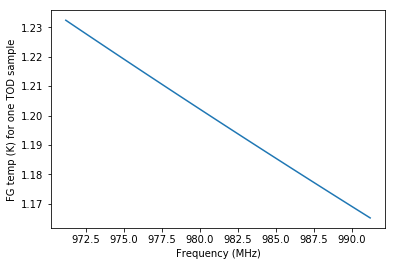

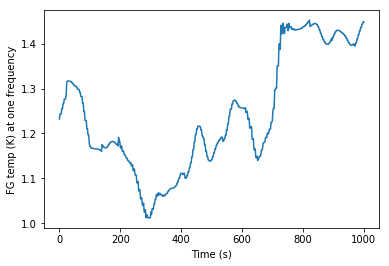

In [7]:
plt.plot(freq_range, the_fgs[0,0,:])
plt.xlabel('Frequency (MHz)')
plt.ylabel('FG temp (K) for one TOD sample')
plt.show()

plt.plot(np.linspace(0, 2*the_fgs.shape[1], the_fgs.shape[1]), the_fgs[0,:,0])
plt.xlabel('Time (s)')
plt.ylabel('FG temp (K) at one frequency')
plt.show()